In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RESULTS_DIR = Path("../results")

In [3]:
# Detect the project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROC_DIR = DATA_DIR / "processed"   # train/test files shared with the team
FIGDIR = PROJECT_ROOT / "reports" / "figures"

for d in (FIGDIR, PROC_DIR):
    d.mkdir(parents=True, exist_ok=True)

### Load the results : 

In [4]:
rows = []
for f in sorted(RESULTS_DIR.glob("*_models.json")):
    with open(f) as fh:
        entries = json.load(fh)
    # Older files may wrap the list in a dict; handle both shapes.
    if isinstance(entries, dict):
        entries = entries.get("models", [])
    for e in entries:
        rows.append({"notebook": f.stem.split("_")[0], **e})

res = pd.DataFrame(rows)
res["label"] = res["model"] + " (" + res["notes"].fillna("—") + ")"
ranked = res.sort_values("gini", ascending=False)

print(f"{len(res)} entries loaded from {res['notebook'].nunique()} notebooks")
ranked[["notebook", "model", "notes", "auc", "gini", "ap"]]

26 entries loaded from 4 notebooks


,notebook,model,notes,auc,gini,ap
13,03,CatBoost,"hold-out 80/20, without calc",0.642800,0.285600,0.068900
5,01,XGBoost,without calc,0.642300,0.284600,0.068300
12,03,CatBoost,"hold-out 80/20, with calc",0.641800,0.283600,0.068600
24,04,Best Weighted Average,without calc; same configuration as the with-c...,0.641700,0.283400,0.065600
25,04,Stacking,without calc; same configuration as the with-c...,0.641700,0.283400,0.065400
4,01,XGBoost,with calc,0.641300,0.282500,0.067600
22,04,XGBoost,without calc; same configuration as the with-c...,0.641100,0.282200,0.067500
7,01,Stacking,without calc,0.640900,0.281900,0.068200
18,04,Weighted Average (XGBoost + SVM),Weighted averaging ensemble; weights selected ...,0.640445,0.280890,0.065069
19,04,Stacking (XGBoost + SVM),Stacking ensemble with Logistic Regression as ...,0.640438,0.280876,0.064852


#### Best models per group member : 

In [5]:
res["variant"] = np.where(
    res["notes"].str.contains("without calc", case=False, na=False),
    "without calc", "with calc")

wide = (res.pivot_table(index=["notebook", "model"], columns="variant",
                        values="gini", aggfunc="max")
           .reset_index())
for c in ["with calc", "without calc"]:
    if c not in wide.columns:
        wide[c] = np.nan

wide["best"] = wide[["with calc", "without calc"]].max(axis=1)
best = (wide.sort_values("best", ascending=False)
            .groupby("notebook", as_index=False).first())

MEMBERS = {"01": "Leyla", "02": "Dangui", "03": "Mariam", "04": "Gilles"}
best.insert(1, "member", best["notebook"].map(MEMBERS))
best["delta"] = best["without calc"] - best["with calc"]
best = best.sort_values("best", ascending=False)

best_df = (best[["notebook", "member", "model",
                 "with calc", "without calc", "delta"]]
           .reset_index(drop=True)
           .round(4))
best_df


variant,notebook,member,model,with calc,without calc,delta
0,03,Mariam,CatBoost,0.2836,0.2856,0.0020
1,01,Leyla,XGBoost,0.2825,0.2846,0.0021
2,04,Gilles,Best Weighted Average,0.2795,0.2834,0.0039
3,02,Dangui,LightGBM,0.2740,0.2741,0.0001


### Plot : 

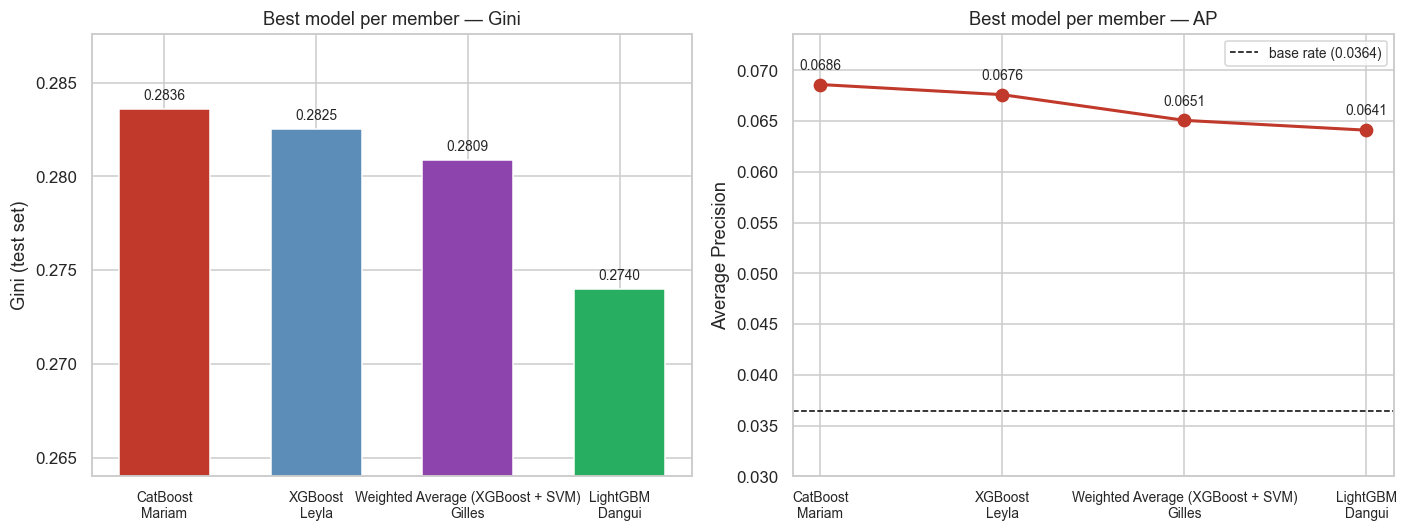

In [16]:
# Best model per notebook based on Gini — WITH calc only
best_with_calc = (
    res[res["notes"].str.contains("without calc", case=False, na=False) == False]
    .sort_values("gini", ascending=False)
    .groupby("notebook", as_index=False)
    .first()
)

d = best_with_calc[["notebook", "model", "gini", "ap"]].copy()

d = d.sort_values("gini", ascending=False).reset_index(drop=True)

d.insert(1, "member", d["notebook"].map(MEMBERS))

x = np.arange(len(d))
labels = d["model"] + "\n" + d["member"]

palette = {
    "01": "#5b8db8",
    "02": "#27ae60",
    "03": "#c0392b",
    "04": "#8e44ad"
}
colors = [palette[n] for n in d["notebook"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Gini ---
bars = ax1.bar(x, d["gini"], 0.6, color=colors)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("Gini (test set)")
ax1.set_ylim(d["gini"].min() - 0.010, d["gini"].max() + 0.004)
ax1.set_title("Best model per member — Gini")
ax1.grid(True, axis="y", zorder=-3)

for r, v in zip(bars, d["gini"]):
    ax1.text(
        r.get_x() + r.get_width()/2,
        v + 0.0005,
        f"{v:.4f}",
        ha="center",
        fontsize=9
    )

# --- AP ---
ax2.plot(x, d["ap"], marker="o", ms=8, lw=2, color="#c0392b")
ax2.axhline(
    0.0364,
    color="black",
    ls="--",
    lw=1,
    label="base rate (0.0364)"
)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Average Precision")
ax2.set_ylim(0.030, d["ap"].max() + 0.005)
ax2.set_title("Best model per member — AP")
ax2.legend(fontsize=9)
ax2.grid(True, zorder=-3)

for xi, v in zip(x, d["ap"]):
    if pd.notna(v):
        ax2.text(
            xi,
            v + 0.0015,
            f"{v:.4f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.savefig(FIGDIR / "group_best_gini_ap_with_calc.png",
            dpi=150, bbox_inches="tight")
plt.show()

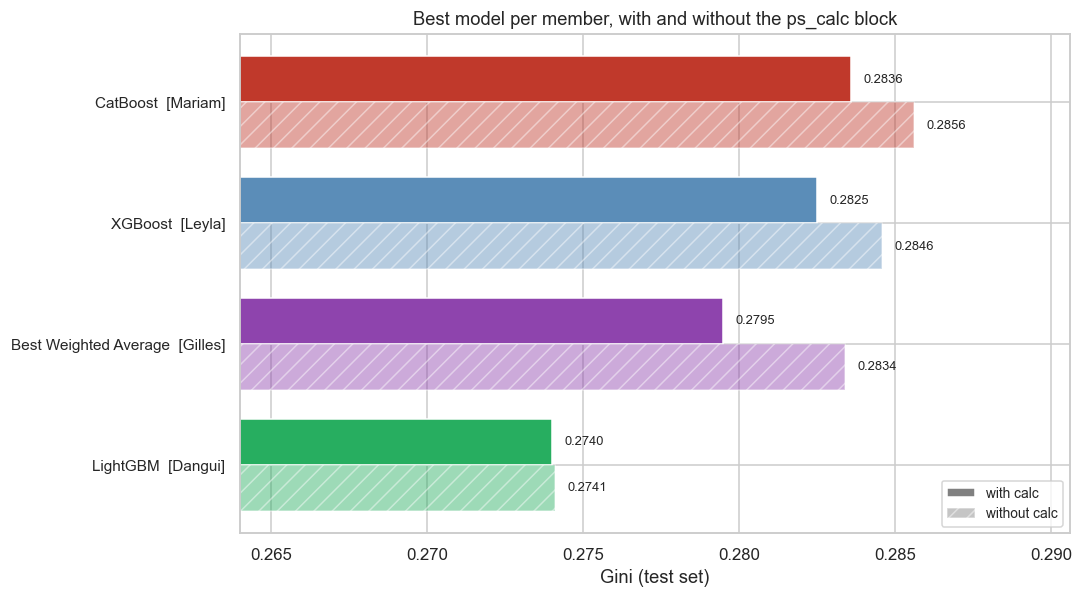

In [10]:
d = best_df.copy()
d["best"] = d[["with calc", "without calc"]].max(axis=1)
d = d.sort_values("best")

y = np.arange(len(d))
h = 0.38
labels = d["model"] + "  [" + d["member"] + "]"

palette = {"01": "#5b8db8", "02": "#27ae60", "03": "#c0392b", "04": "#8e44ad"}
colors = [palette[n] for n in d["notebook"]]

plt.figure(figsize=(10, 0.9 * len(d) + 2))

plt.barh(y + h/2, d["with calc"], h, color=colors)
plt.barh(y - h/2, d["without calc"], h, color=colors, alpha=0.45,
         hatch="//", edgecolor="white")

plt.yticks(y, labels, fontsize=10)
plt.xlabel("Gini (test set)")
lo = d[["with calc", "without calc"]].min().min()
hi = d[["with calc", "without calc"]].max().max()
plt.xlim(lo - 0.010, hi + 0.005)
plt.title("Best model per member, with and without the ps_calc block")
plt.grid(True, axis="x", zorder=-3)

for i, (a, b) in enumerate(zip(d["with calc"], d["without calc"])):
    if pd.notna(a): plt.text(a + 0.0004, i + h/2, f"{a:.4f}", va="center", fontsize=8.5)
    if pd.notna(b): plt.text(b + 0.0004, i - h/2, f"{b:.4f}", va="center", fontsize=8.5)

from matplotlib.patches import Patch
handles = [Patch(facecolor="grey", label="with calc"),
           Patch(facecolor="grey", alpha=0.45, hatch="//", label="without calc")]
plt.legend(handles=handles, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(FIGDIR / "group_best_calc_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

### Best Model : 

In [14]:
best = ranked.iloc[0]
print(f"Best model: {best['model']}  (notebook {best['notebook']}, {best['notes']})")
print(f"  AUC  {best['auc']:.4f}")
print(f"  Gini {best['gini']:.4f}")
if pd.notna(best["ap"]):
    print(f"  AP   {best['ap']:.4f}  ({best['ap']/best['base_rate']:.2f}x base rate)")
print("\nParameters:")
for k, v in best["params"].items():
    print(f"  {k}: {v}")

Best model: CatBoost  (notebook 03, hold-out 80/20, without calc)
  AUC  0.6428
  Gini 0.2856
  AP   0.0689  (1.89x base rate)

Parameters:
  loss_function: Logloss
  eval_metric: AUC
  iterations: 2000
  learning_rate: 0.03
  depth: 7
  l2_leaf_reg: 5
  random_strength: 1.0
  random_seed: 42
  best_iteration: 937
  early_stopping_rounds: 150
